<a href="https://colab.research.google.com/github/LukicMatija/NJTProjekat/blob/main/MatijaLukic20220079_NAP_AirlineReviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Importovanje funkcija

In [ ]:
#Pandas koristimo za rad sa data setom
import pandas as pd
#Koristi se za matematicke operacije i rad sa nizovima brojeva
import numpy as np
#Graficki prikaz
import matplotlib.pyplot as plt
#Biblioteka za naprednu vizuelizaciju
import seaborn as sns
#Glavni algoritam za grupisanje podataka u klastere
from sklearn.cluster import KMeans
#Metrika za ocenjivanje kvaliteta i razdvojenosti klastera
from sklearn.metrics import silhouette_score
#Model koji pretvara tekstualne recenzije u numericke vektore (embeddinge)
from sentence_transformers import SentenceTransformer
#Alat za izdvajanje najcescih kljucnih reci iz svake grupe recenzija
from sklearn.feature_extraction.text import CountVectorizer
#Vizuelizacija klaster
from sklearn.decomposition import PCA
#Upload fajla
from google.colab import files

#2. Ucitavanje podataka

In [ ]:
uploaded = files.upload()

Saving Airline_review.csv to Airline_review.csv


In [ ]:
df = pd.read_csv('Airline_review.csv')
print(f"Broj komentara: {len(df)}")

Broj komentara: 23171


#3. Redukcija dataseta
Redukcija dataseta na 60 avio kompanija. Takodje su uzeti za razmatranje samo recenzije od strane verifikovanih korisnika.

In [ ]:
#Izdvajamo samo recenzije verifikovanih korisnika
df_verified = df[df['Verified'] == True].copy()
#Samo 60 avio kompanija sa najvise recenzija
top_airlines = df_verified['Airline Name'].value_counts().nlargest(60).index
df_reduced = df_verified[df_verified['Airline Name'].isin(top_airlines)].copy()
print(f"Velicina uzorka: {len(df_reduced)}")

Velicina uzorka: 4893


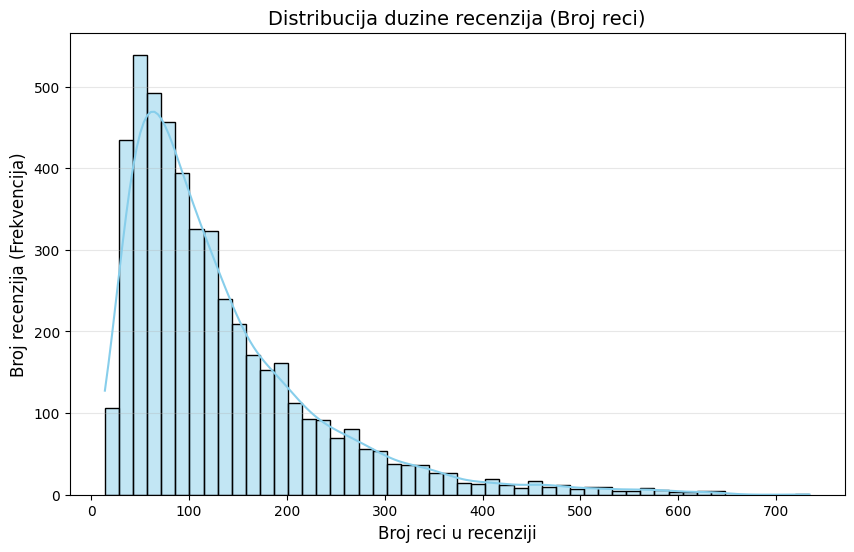

Prosecna duzina: 132.0 reci
Medijana duzine: 102.0 reci
Najduza recenzija: 734 reci


In [ ]:
#Racunanje broja reci
#unkcija .split() deli tekst na razmake, a len() broji te delove
df_reduced['Review_Length'] = df_reduced['Review'].apply(lambda x: len(str(x).split()))

#Vizuelizacija
plt.figure(figsize=(10, 6))

#Histogram prikazuje broj recenzija (Y osa) za odredjenu duzinu (X osa)
sns.histplot(df_reduced['Review_Length'], bins=50, kde=True, color='skyblue')

plt.title('Distribucija duzine recenzija (Broj reci)', fontsize=14)
plt.xlabel('Broj reci u recenziji', fontsize=12)
plt.ylabel('Broj recenzija (Frekvencija)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

#Osnovni statisticki podaci
print(f"Prosecna duzina: {df_reduced['Review_Length'].mean():.1f} reci")
print(f"Medijana duzine: {df_reduced['Review_Length'].median()} reci")
print(f"Najduza recenzija: {df_reduced['Review_Length'].max()} reci")

#4. Numericka reprezentacija teksta (Embedding)
U ovom radu koristili smo all-MiniLM-L6-v2 model, koji pripada porodici SBERT (Sentence-BERT) transformera. Za razliku od klasicnih metoda kao sto su Bag-of-Words ili TF-IDF, koje recenice posmatraju samo kao skupove karaktera, embedding modeli pretvaraju tekst u visedimenzionalne vektore (u nasem slucaju niz od 384 decimalna broja).

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Generisanje embedding-a")
embeddings = model.encode(df_reduced['Review'].tolist(), show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generisanje embedding-a


Batches:   0%|          | 0/153 [00:00<?, ?it/s]

#5. Evaluacija modela (Elbow i silhouette)
Testiramo razlicite vrednosti K (broj grupa) da bismo dokazali izbor.
Elbow (crveno) pokazuje gde opada dobitak u preciznosti. Silhouette (plavo) pokazuje koliko su grupe jasno razgranicene

Za k=2, Silhouette Score je: 0.0645
Za k=3, Silhouette Score je: 0.0429
Za k=4, Silhouette Score je: 0.0419
Za k=5, Silhouette Score je: 0.0404
Za k=6, Silhouette Score je: 0.0381
Za k=7, Silhouette Score je: 0.0367
Za k=8, Silhouette Score je: 0.0371
Za k=9, Silhouette Score je: 0.0351
Za k=10, Silhouette Score je: 0.0345
Za k=11, Silhouette Score je: 0.0363
Za k=12, Silhouette Score je: 0.0347
Za k=13, Silhouette Score je: 0.0349
Za k=14, Silhouette Score je: 0.0303
Za k=15, Silhouette Score je: 0.0309
Za k=16, Silhouette Score je: 0.0328
Za k=17, Silhouette Score je: 0.0323
Za k=18, Silhouette Score je: 0.0321
Za k=19, Silhouette Score je: 0.0332
Za k=20, Silhouette Score je: 0.0328


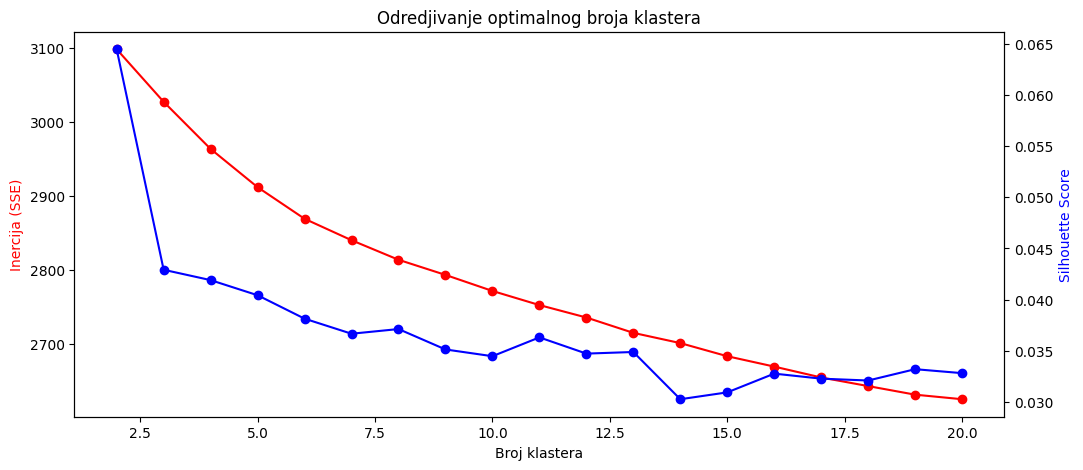

In [ ]:
sse = []
silhouette_avg = []
k_range = range(2, 21) # Testiramo od 2 do 20 tema

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings)
    sse.append(kmeans.inertia_)
    score = silhouette_score(embeddings, labels) # Racunanje
    silhouette_avg.append(score)
    print(f"Za k={k}, Silhouette Score je: {score:.4f}")

# Vizuelizacija rezultata
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(k_range, sse, 'ro-', label='Elbow (SSE)')
ax1.set_xlabel('Broj klastera')
ax1.set_ylabel('Inercija (SSE)', color='r')
ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_avg, 'bo-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='b')
plt.title('Odredjivanje optimalnog broja klastera')
plt.show()

#6. Klasterizacija (K-means)
Automatski odabran broj klastera ce biti onaj broj sa najvecim silhouette score-om.

Odabran broj klastera: 2


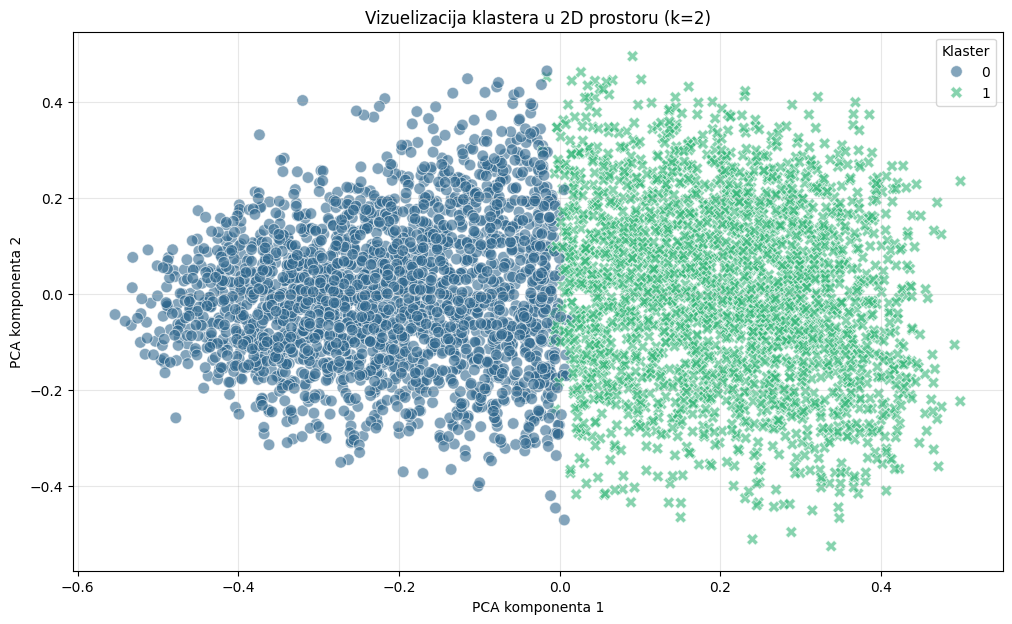

In [ ]:
#Odabir optimalnog broja klastera
optimal_k = k_range[np.argmax(silhouette_avg)]
print(f"Odabran broj klastera: {optimal_k}")
#Kmeans
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_reduced['Cluster'] = kmeans_final.fit_predict(embeddings)
pca = PCA(n_components=2, random_state=42)
pca_2d = pca.fit_transform(embeddings)
#Vizuelizacija klastera
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x=pca_2d[:, 0], y=pca_2d[:, 1],
    hue=df_reduced['Cluster'],
    palette='viridis',
    style=df_reduced['Cluster'],
    s=70, alpha=0.6
)
plt.title(f'Vizuelizacija klastera u 2D prostoru (k={optimal_k})')
plt.xlabel('PCA komponenta 1')
plt.ylabel('PCA komponenta 2')
plt.legend(title='Klaster')
plt.grid(True, alpha=0.3)
plt.show()

Zbog naglog pada inercije kod 3 klastera odradicemo vizuelizaciju i 3 klastera.

Odabran broj klastera: 3


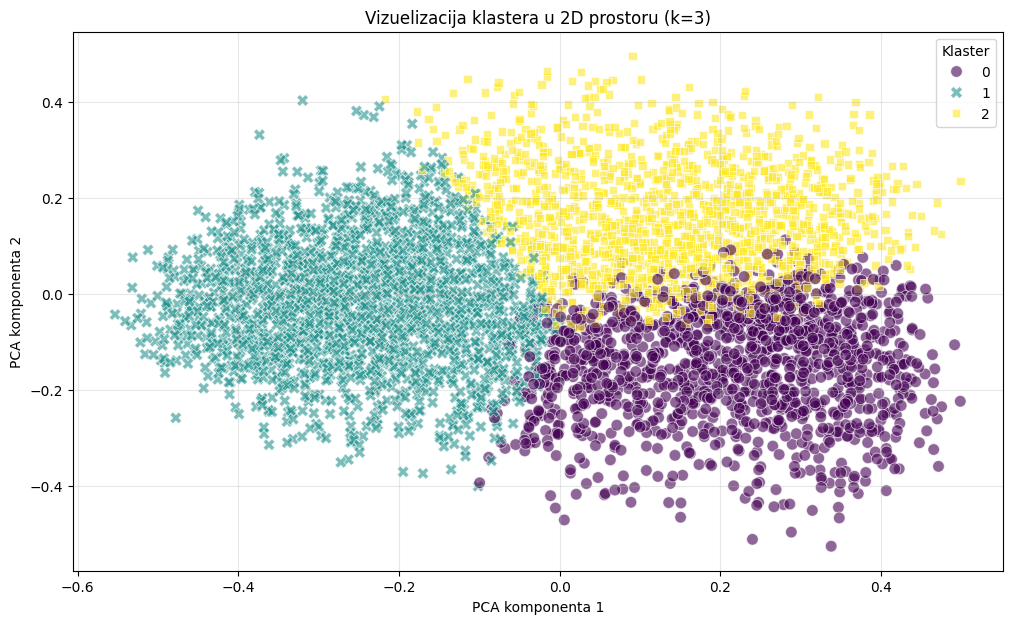

In [ ]:
#Odabir 3 klastera
optimal_k = 3
print(f"Odabran broj klastera: {optimal_k}")
#Kmeans
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_reduced['Cluster'] = kmeans_final.fit_predict(embeddings)
pca = PCA(n_components=2, random_state=42)
pca_2d = pca.fit_transform(embeddings)
#Vizuelizacija klastera
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x=pca_2d[:, 0], y=pca_2d[:, 1],
    hue=df_reduced['Cluster'],
    palette='viridis',
    style=df_reduced['Cluster'],
    s=70, alpha=0.6
)
plt.title(f'Vizuelizacija klastera u 2D prostoru (k={optimal_k})')
plt.xlabel('PCA komponenta 1')
plt.ylabel('PCA komponenta 2')
plt.legend(title='Klaster')
plt.grid(True, alpha=0.3)
plt.show()

Iako **k = 2** ima veci silhouette score odabrao sam **k = 3**. Uradjeno je iz razloga zato sto podela na 2 klastera je trivijalna. Dobijamo podelu na dobre i lose recenzije. Trecim klasterom dobijamo novu grupu putnika koja je neutrala. Na primer zadovoljni su uslugom, ali nisu zadovoljni hranom i picem.

In [ ]:
# Racunamo broj recenzija i procenat po klasterima
counts = df_reduced['Cluster'].value_counts().sort_index()
percentages = df_reduced['Cluster'].value_counts(normalize=True).sort_index() * 100

print("VELICINA KLASTERA")
for i in range(len(counts)):
    print(f"Klaster {i}: {counts[i]} recenzija ({percentages[i]:.2f}%)")

VELICINA KLASTERA
Klaster 0: 1357 recenzija (27.73%)
Klaster 1: 2007 recenzija (41.02%)
Klaster 2: 1529 recenzija (31.25%)


Iz ovoga mozemo zakljuciti da najvise ima nezadovoljnih putnika.

#7. Tekstualna interpretacija

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text
import spacy

#Ucitavamo engleski model za lematizaciju
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def lemmatize_text(text):
    doc = nlp(text.lower())
    #Uzimamo samo reci koje su imenice, pridevi ili glagoli i vracamo ih u osnovni oblik
    return " ".join([token.lemma_ for token in doc if token.is_alpha and not token.is_stop])

#Primenjujemo lematizaciju na sve recenzije
df_reduced['Lemmatized_Review'] = df_reduced['Review'].apply(lemmatize_text)
#Definisanje stopwords-a
#Dodajemo reci koje se pojavljuju u svakoj avio recenziji
custom_stopwords = ['flight', 'airline', 'flights', 'service', 'time', 'plane', 'get', 'would', 'one', 'airlines', 'air', 'airport', 'check', 'cabin']
final_stopwords = list(text.ENGLISH_STOP_WORDS.union(custom_stopwords))

tfidf = TfidfVectorizer(stop_words=final_stopwords, ngram_range=(1, 2), max_features=15)

for i in range(optimal_k):
    #Uzimamo tekst samo za odredjeni klaster
    cluster_docs = df_reduced[df_reduced['Cluster'] == i]['Lemmatized_Review']
    #Treniramo model na tekstu klastera
    tfidf_matrix = tfidf.fit_transform(cluster_docs)
    #Uzimamo nazive reci
    terms = tfidf.get_feature_names_out()
    print(f"\nKlaster {i} najcesci termini: {list(terms)}")

    #Racunamo prosek preporuka
    rec_rate = df_reduced[df_reduced['Cluster'] == i]['Recommended'].value_counts(normalize=True).get('yes', 0) * 100
    print(f"Procenat preporuka u ovom klasteru: {rec_rate:.2f}%")


Klaster 0 najcesci termini: ['bad', 'bangkok', 'class', 'comfortable', 'crew', 'delay', 'experience', 'fly', 'food', 'good', 'great', 'hour', 'meal', 'seat', 'staff']
Procenat preporuka u ovom klasteru: 66.84%

Klaster 1 najcesci termini: ['bag', 'book', 'cancel', 'customer', 'day', 'delay', 'fly', 'hour', 'luggage', 'pay', 'refund', 'seat', 'staff', 'tell', 'ticket']
Procenat preporuka u ovom klasteru: 6.68%

Klaster 2 najcesci termini: ['boarding', 'business', 'class', 'crew', 'drink', 'experience', 'fly', 'food', 'good', 'hour', 'meal', 'passenger', 'seat', 'serve', 'staff']
Procenat preporuka u ovom klasteru: 54.74%


Iz ove analize mozemo zakljuciti sledece:
  1. Klaster 1: Ovaj klaster je kljucan za analizu. Sa stopom preporuke od svega 6.68%, ovo je grupa ekstremno nezadovoljnih putnika. Kljucni pojmovi poput *hour, refund, delay, luggage* i *tell* ukazuju na to da se ovde ne radi o sitnicama poput lose hrane, vec o ozbiljnim problemima u sistemu. Rec *tell* (rekli su mi...) sugerise na frustrirajucu komunikaciju sa osobljem nakon sto je let otkazan ili prtljag izgubljen.
  2. Klaster 0: Sa 66.84% preporuka, ovo je najuspesniji klaster. Reci poput *great, good, crew* i *food* dominiraju. Ovde vidimo da su udobnost i kvalitet usluge bili presudni faktori koji su doveli do visoke ocene. Putnici iz ove grupe su doziveli let upravo onako kako je planirano.
  3. Klaster 2: Ovde imamo solidnih 54.74% preporuka. Pojmovi *business, class, boarding* i *passengers* ukazuju na to da su ovo putnici koji vise paznje pridaju logistici i samom procesu putovanja. Ocene su dobre, ali nize nego u Klasteru 0, sto znaci da su ovi putnici zahtevniji i imaju visa ocekivanja od samog brenda.

Pojava termina poput 'bad' i 'delay' u Klasteru 0, koji dominira pozitivnim recenzijama (66.84% preporuka), ne ukazuje na gresku u modelu, vec na kompleksnost ljudskog izrazavanja. U sledecem kodu izdvojen je jedan takav primer.

In [ ]:
primer = df_reduced[(df_reduced['Cluster'] == 0) & (df_reduced['Review'].str.contains('bad', case=False))]['Review'].iloc[0]
print(primer)

 Great airline! I fly regularly with Aegean Airlines, and it is always my number one choice. Especially the new planes are really nice, and the service on board is good too. The food is really not that bad, especially in business class. However, Economy is great as well. There are some nice touches with Aegean, like how they inform you when your flight is delayed. They email you, and you get a notification in the app. About the app, it works really good. One of the best airline apps I have tried so far! I don't have any complaints. Even after dozens of flights, no problems at all!


#8. Heatmap

In [ ]:
#Numericke kolone
rating_cols = ['Seat Comfort', 'Cabin Staff Service', 'Food & Beverages',
               'Ground Service', 'Value For Money']
cluster_profile = df_reduced.groupby('Cluster')[rating_cols].mean()

print("\nProsecne ocene po klasterima:")
print(cluster_profile)


Prosecne ocene po klasterima:
         Seat Comfort  Cabin Staff Service  Food & Beverages  Ground Service  \
Cluster                                                                        
0            3.546338             3.883146          3.518810        3.505551   
1            2.082192             2.296438          2.058447        1.454859   
2            3.219223             3.429420          3.010401        3.214005   

         Value For Money  
Cluster                   
0               3.571113  
1               1.529646  
2               3.207325  


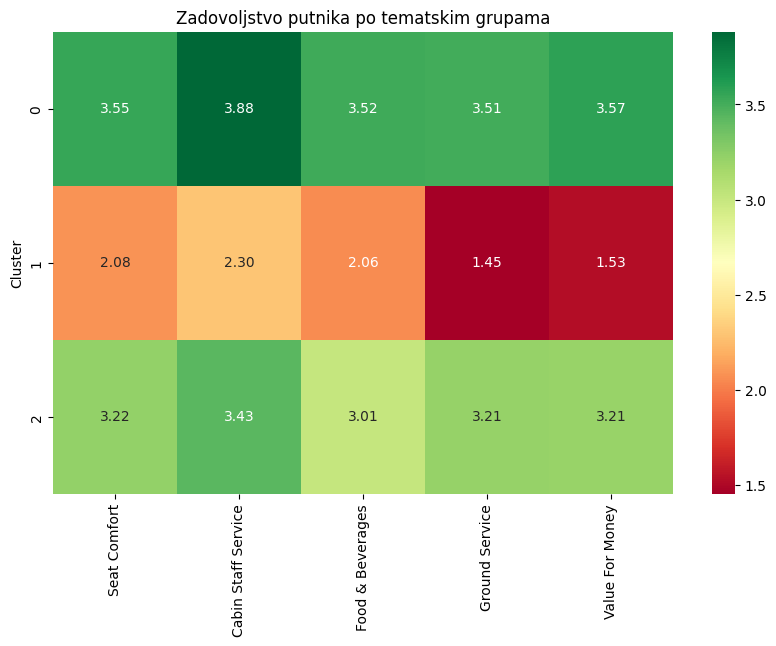

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Zadovoljstvo putnika po tematskim grupama')
plt.show()

Heatmap vizuelizacija je potvrdila jasnu vezu izmedju onoga sto putnici pisu i ocena koje daju. Klasteri sa pozitivnim semantickim tonovima dosledno imaju visoke numericke vrednosti, sto dokazuje validnost koriscenih K-means algoritama u analizi korisnickog iskustva.

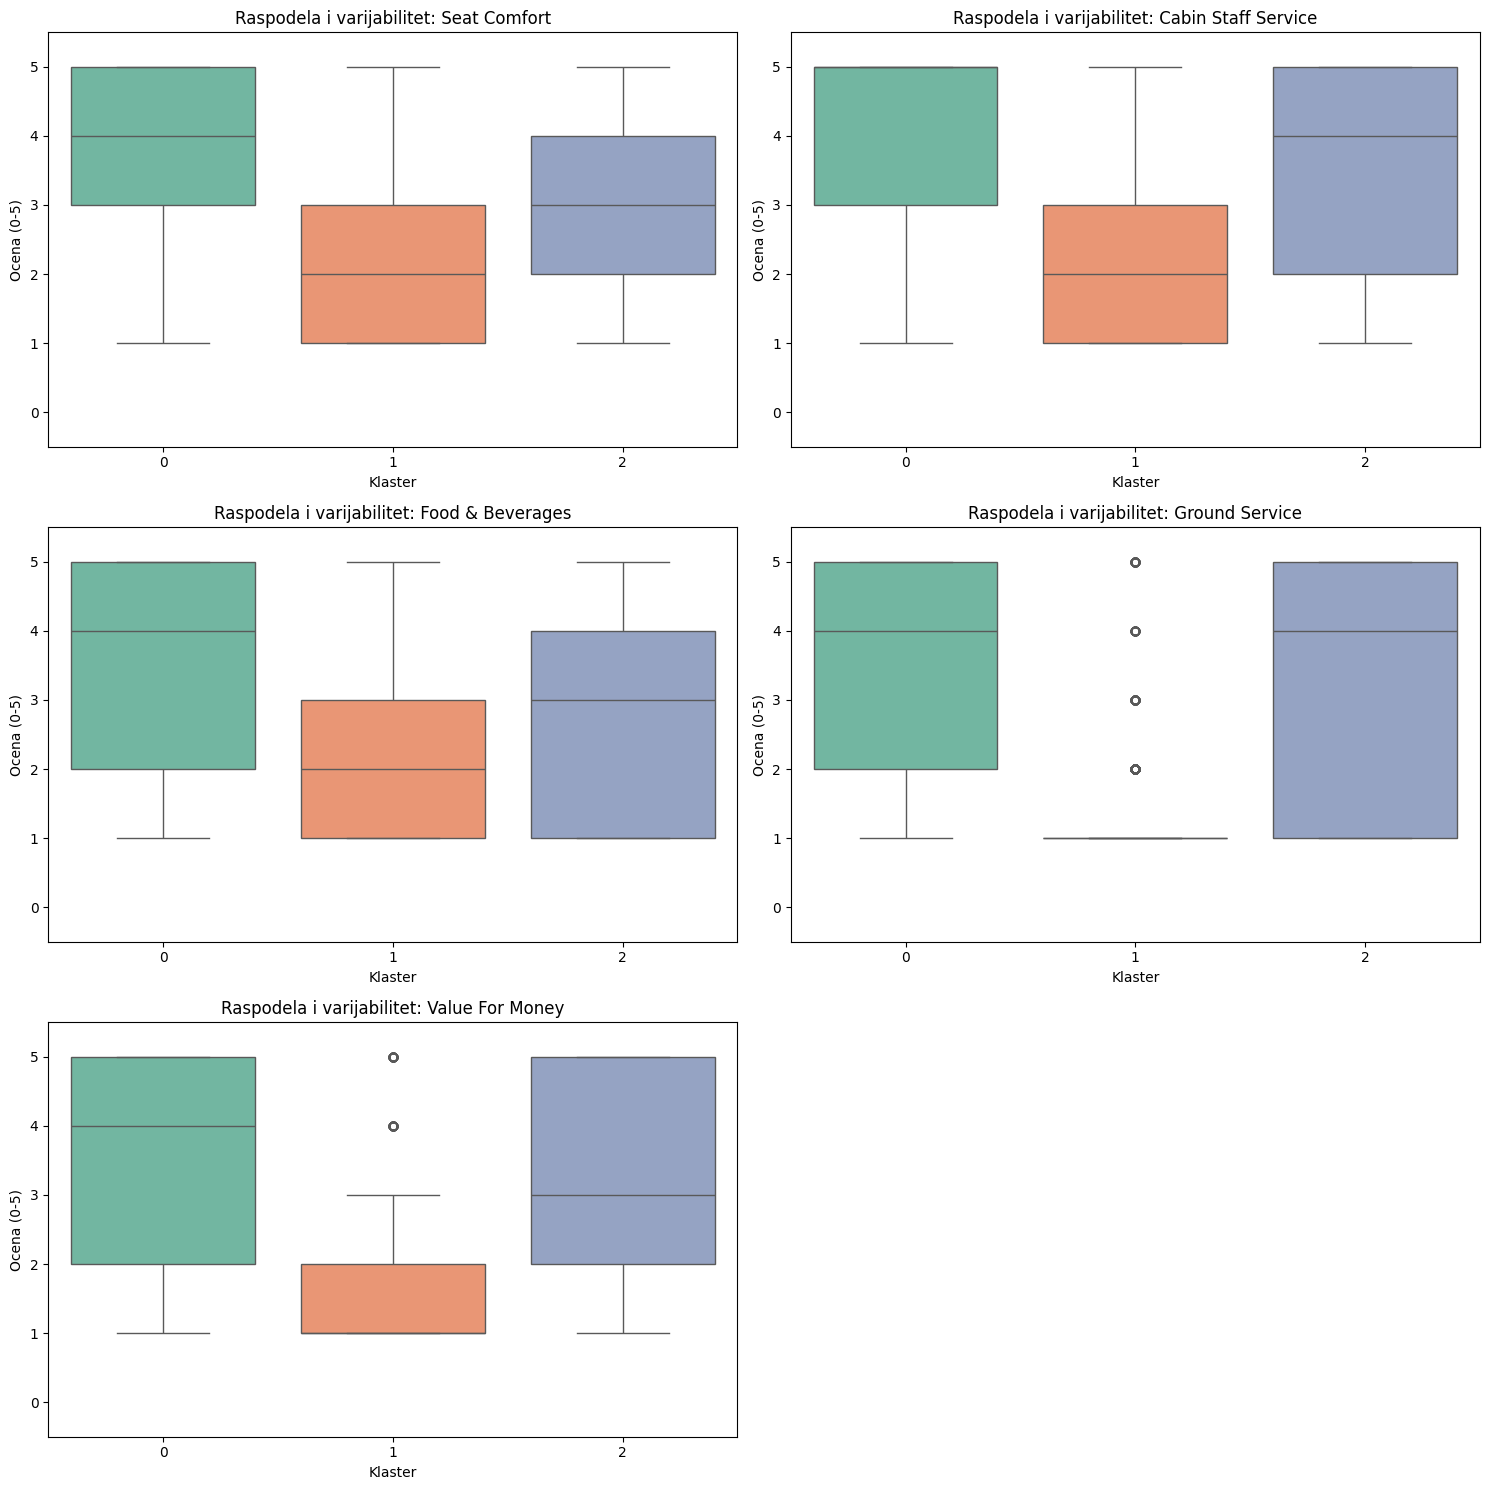


--- DETALJNA STATISTIKA PO KLASTERIMA ---
        Seat Comfort       Cabin Staff Service       Food & Beverages        \
              median   std              median   std           median   std   
Cluster                                                                       
0                4.0  1.43                 5.0  1.43              4.0  1.50   
1                2.0  1.18                 2.0  1.36              2.0  1.23   
2                3.0  1.44                 4.0  1.58              3.0  1.55   

        Ground Service       Value For Money        
                median   std          median   std  
Cluster                                             
0                  4.0  1.60             4.0  1.57  
1                  1.0  1.02             1.0  1.02  
2                  4.0  1.58             3.0  1.53  


In [ ]:
import math
# Biramo najvaznije kolone za prikaz
rating_cols = ['Seat Comfort', 'Cabin Staff Service', 'Food & Beverages',
               'Ground Service', 'Value For Money']

#Priprema mreze za grafikone
num_plots = len(rating_cols)
cols_grid = 2
rows_grid = math.ceil(num_plots / cols_grid)

plt.figure(figsize=(15, 5 * rows_grid))

#Crtanje grafikona
for i, col in enumerate(rating_cols, 1):
    plt.subplot(rows_grid, cols_grid, i)
    sns.boxplot(x='Cluster', y=col, data=df_reduced, hue='Cluster', palette='Set2', legend=False)

    plt.title(f'Raspodela i varijabilitet: {col}', fontsize=12)
    plt.ylabel('Ocena (0-5)')
    plt.xlabel('Klaster')
    plt.ylim(-0.5, 5.5)

plt.tight_layout()
plt.show()

#(Medijana i Standardna devijacija)
#Ovo je direktan odgovor na profesorkino pitanje o informativnosti
print("\n--- DETALJNA STATISTIKA PO KLASTERIMA ---")
stats = df_reduced.groupby('Cluster')[rating_cols].agg(['median', 'std']).round(2)
print(stats)

1. **Klaster 0** (zeleni) dosledno pokazuje najvise ocene u svim kategorijama, sa medijanom 4.0, sto ga definise kao segment zadovoljnih i lojalnih putnika.

2. **Klaster 1** (narandzasti) predstavlja segment putnika sa najlosijim iskustvom, gde su ocene za zemaljske usluge (Ground Service) i udobnost (Seat Comfort) drasticno nize u odnosu na ostatak uzorka. Prisustvo outliera u ovom klasteru ukazuje na to da cak i kod ekstremno nezadovoljnih putnika postoje izolovani aspekti usluge koji su ocenjeni bolje, ali oni ne menjaju opsti negativan utisak.

3. **Klaster 2** (plavi) karakterise najveci varijabilitet (raspon) ocena, sto sugerise da se radi o putnicima sa umerenim ocekivanjima ili razlicitim iskustvima u zavisnosti od klase leta.

Koriscenje boxplot-ova umesto proste srednje vrednosti omogucilo je uvid u stabilnost usluge. Dok su ocene u Klasteru 0 stabilno visoke (mala kutija), ocene u Klasteru 2 variraju, sto ukazuje na nekonzistentnost u kvalitetu hrane i udobnosti za tu grupu putnika.

#9. Zakljucak
Ovo istrazivanje je pokazalo da koriscenje naprednih NLP modela (BERT) u kombinaciji sa klasterizacijom (K-means) daje mnogo dublji uvid u zadovoljstvo korisnika nego klasicne metode analize.

1. Validnost podele na tri segmenta:
Iako je statisticki score (Silhouette) blago favorizovao dva klastera, odluka da zadrzimo tri klastera se pokazala kao ispravna sa poslovne tacke gledista. Dobili smo tri jasno definisana profila putnika:

    Klaster 0 (Zeleni): Putnici ciji je fokus na vrhunskom iskustvu (hrana, osoblje, komfor).

    Klaster 1 (Narandzasti): Putnici pogodjeni operativnim problemima (kasnjenja, prtljag, komunikacija).

    Klaster 2 (Plavi): Putnici sa umerenim ocekivanjima (biznis/standard segment).

2. Povezanost reci i ocena:
Analiza je potvrdila savrsenu korelaciju izmedju onoga sto putnici pisu i kako ocenjuju uslugu:

    U Klasteru 1, gde su dominantne reci bile "refund", "luggage" i "told", Boxplot dijagrami su pokazali najnize medijane (ocena 1 i 2) i najnizu stopu preporuke od svega 6.68%. To dokazuje da su ovi putnici pisali o konkretnim "bolnim tackama".

    U Klasteru 0, gde preovladjuju reci "good" i "great", numericke ocene su stabilno visoke, sto potvrdjuje da su meki faktori usluge (osoblje) kljucni za lojalnost brendu.

3. Statisticka stabilnost (Boxplot i Varijabilitet):
    
    Zahvaljujuci boxplot vizuelizaciji, utvrdjeno je da Ground Service (zemaljska usluga) predstavlja najvecu tacku nezadovoljstva za "narandzastu" grupu. Mala varijabilnost (uska kutija) kod niskih ocena u ovom klasteru ukazuje na to da je nezadovoljstvo bilo univerzalno, a ne subjektivno.